# Land Cover Analysis

This notebook analyzes land cover data from Algeria and Tunisia using the shapefile datasets. We'll explore different land cover types and their relationship with fire occurrences.

In [1]:
import os
import multiprocessing

def configure_threading(max_threads=None):
    """Set thread env variables so numeric libs leverage multiple CPU cores."""
    if max_threads is None:
        max_threads = multiprocessing.cpu_count()
    thread_env_vars = [
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ]
    for var in thread_env_vars:
        os.environ[var] = str(max_threads)
    print(f"Threading configured to use up to {max_threads} CPU cores.")

configure_threading()

Threading configured to use up to 12 CPU cores.


In [2]:
# Import required libraries
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style using seaborn
# use seaborn's theme function instead of matplotlib's style to avoid OSError
sns.set_theme(style='darkgrid', palette='husl')

# Load the shapefiles
algeria_lc = gpd.read_file('../dataset/land_cover_dataset/algeria/dza_gc_adg.shp')
tunisia_lc = gpd.read_file('../dataset/land_cover_dataset/tunisia/Tunisia_LC_2022_point_data.shp')

# Harmonize CRS so boundaries align
if tunisia_lc.crs != algeria_lc.crs:
    tunisia_lc = tunisia_lc.to_crs(algeria_lc.crs)

In [3]:
# Build country boundaries from land cover layers and persist them
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

def build_boundary(gdf):
    """Return a single-geometry GeoDataFrame representing the dataset boundary."""
    if gdf.empty:
        raise ValueError('Input GeoDataFrame is empty; cannot derive boundary.')
    geom_union = gdf.geometry.unary_union
    if geom_union.is_empty:
        raise ValueError('Unable to derive boundary from input geometries.')
    # If data are points/lines, use convex hull to approximate an area boundary
    if geom_union.geom_type in {'Point', 'MultiPoint', 'LineString', 'MultiLineString'}:
        geom_union = geom_union.convex_hull
    return gpd.GeoDataFrame({'geometry': [geom_union]}, crs=gdf.crs)

algeria_boundary = build_boundary(algeria_lc)
tunisia_boundary = build_boundary(tunisia_lc)

algeria_boundary_path = results_dir / 'algeria_boundary.geojson'
tunisia_boundary_path = results_dir / 'tunisia_boundary.geojson'
algeria_boundary.to_file(algeria_boundary_path, driver='GeoJSON')
tunisia_boundary.to_file(tunisia_boundary_path, driver='GeoJSON')
print(f"Saved Algeria boundary to {algeria_boundary_path.resolve()}")
print(f"Saved Tunisia boundary to {tunisia_boundary_path.resolve()}")

C:\Users\Azur\AppData\Local\Temp\ipykernel_18364\3492578924.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = gdf.geometry.unary_union


Saved Algeria boundary to C:\Users\Azur\Downloads\TP\DM\results\algeria_boundary.geojson
Saved Tunisia boundary to C:\Users\Azur\Downloads\TP\DM\results\tunisia_boundary.geojson


C:\Users\Azur\AppData\Local\Temp\ipykernel_18364\3492578924.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = gdf.geometry.unary_union


KeyError: 'landcover'

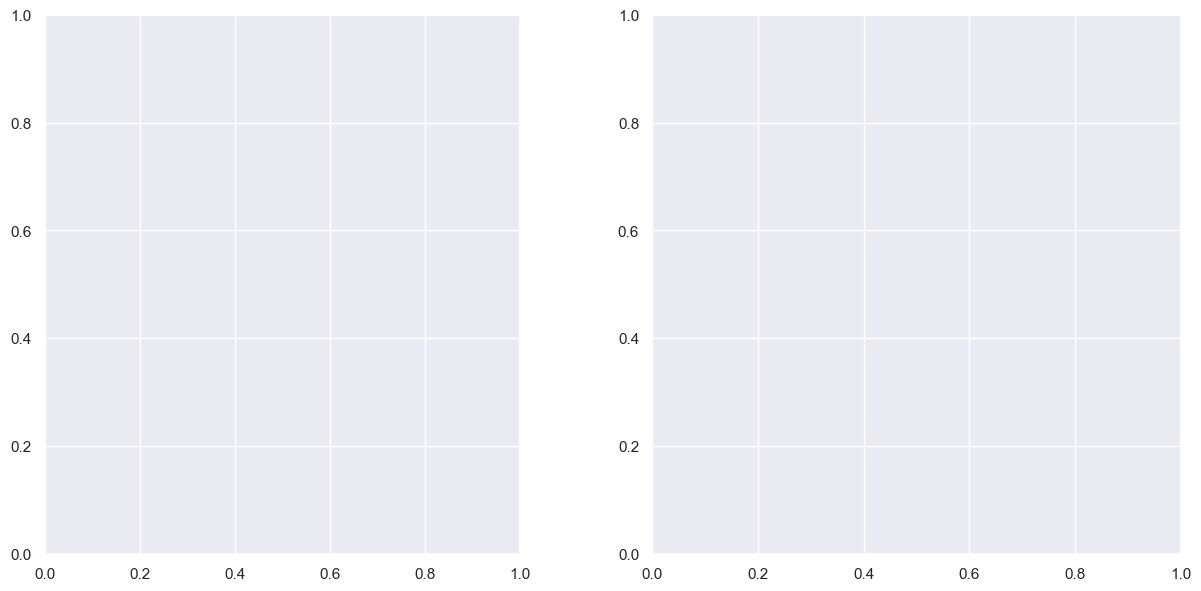

In [4]:
# plot Algeria and Tunisia land cover data
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
algeria_lc.plot(column='landcover', ax=ax[0], legend=True, cmap='Set3')
ax[0].set_title('Algeria Land Cover')
ax[0].axis('off')

tunisia_lc.plot(column='landcover', ax=ax[1], legend=True, cmap='Set3')
ax[1].set_title('Tunisia Land Cover')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Inspect land cover attributes and visualize derived boundaries
print(algeria_lc.head())

# Plot country boundaries generated from land cover datasets
fig, ax = plt.subplots(figsize=(10, 10))
algeria_boundary.plot(ax=ax, color='blue', alpha=0.4, edgecolor='navy', linewidth=1.5, label='Algeria boundary')
tunisia_boundary.plot(ax=ax, color='red', alpha=0.4, edgecolor='darkred', linewidth=1.5, label='Tunisia boundary')
ax.set_title('Boundaries Derived from Land Cover Datasets')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.show()

   ID  GRIDCODE          AREA       LCCCODE  \
0   4       210  6.228187e+06  7001 // 8001   
1   2       210  6.242408e+06  7001 // 8001   
2   1       210  1.482995e+06  7001 // 8001   
3   8        50  4.590841e+08  21497-121340   
4  13       210  6.371533e+06  7001 // 8001   

                                            geometry  
0  POLYGON ((6.41528 37.08696, 6.43103 37.0855, 6...  
1  POLYGON ((7.18084 37.07917, 7.17998 37.08091, ...  
2  POLYGON ((7.37137 37.08194, 7.3709 37.08717, 7...  
3  POLYGON ((6.12361 36.68472, 6.12361 36.69306, ...  
4  POLYGON ((6.26181 37.02361, 6.26193 37.02514, ...  


C:\Users\Azur\AppData\Local\Temp\ipykernel_13604\1709798175.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  algeria_boundary = gpd.GeoDataFrame(geometry=[algeria_lc.unary_union], crs=algeria_lc.crs)
